# Analysis and PLotting script for Model 1 and Model 2.



In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from os import listdir

from scipy.optimize import curve_fit
import concurrent.futures
from itertools import repeat


In [ ]:
# Function definitions

def mcc(tp, tn, fp, fn):
    """ 
    Updated defnition from Wikipedia to account for case in which one of the sums in the denominator is 0 (only if two of the 4 values are 0).
    """
    nsum = np.sum(np.array([tp,tn,fp,fn]) == 0)
    if nsum < 2:
        return (tp*tn-fp*fn)/np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    elif nsum == 2:
        return (tp*tn-fp*fn)
    else:
        return np.nan
    
def read_sim_output(ifile, folder, columnnames, columnnames_tcrs, dt=0.002):
    """  
    Assumes the filename starts with the following "Model9_3Phos" or so, with an underscore inbetween
    """
    _,model,_,CD45_den,pMHC_mdens,k_off,CD45_exclusion,k_CD45,k_lck,fileend= ifile.split('_')
    repeat, fileend = fileend.split('.')
    metadata = pd.DataFrame({
        'model': eval(model),
        'CD45_den':  eval(CD45_den),
        'Lck_den': 200, # hard coded in simulation
        'pMHC_mdens': eval(pMHC_mdens),
        'k_off': eval(k_off),
        'k_CD45': eval(k_CD45),
        'CD45_exclusion': eval(CD45_exclusion),
        'k_lck': eval(k_lck),
        'repeat': eval(repeat),
        }, index=[0])

    dat = pd.read_csv(folder/ifile, header=None)
    dat.columns = columnnames

    tracks = pd.read_csv(folder/ifile.replace('.txt', '_tcrs.txt'), header=None)
    tracks.columns = columnnames_tcrs
    tracks['timestep'] = (tracks['timestep']-1) * 10 + 1
    tracks['time'] = tracks['timestep'] * dt

    ## CHANGE!!! 
    lifetimes = pd.read_json(folder/ifile.replace('.txt', '_tcr_lifetimes_5P.json')) # Adjust name here accordingly!!

    return dat, tracks, metadata, lifetimes

def check_metadata_file(file, CD45_den,pMHC_mdens,CD45_exclusion,k_CD45,k_lck, exclude_str = 'lifetimes'):
    if exclude_str in file:
        return False
    
    _,fmodel,_,fCD45_den,fpMHC_mdens,fk_off,fCD45_exclusion,fk_CD45,fk_lck,ffileend= file.split('_')

    has_CD45_den = eval(fCD45_den) in CD45_den
    has_pMHC_den = eval(fpMHC_mdens) in pMHC_mdens
    has_CD45_e = eval(fCD45_exclusion) in CD45_exclusion
    has_CD45_k = eval(fk_CD45) in k_CD45
    has_lck_k = eval(fk_lck) in k_lck

    return has_CD45_e & has_CD45_den & has_lck_k & has_CD45_k & has_pMHC_den

## Parameter estimations

In [6]:
# Theoretical TCR dwell time calculations
d_tcr  =  0.052     # um^2/s 
r_c = 0.22          # um
# From https://www.pnas.org/doi/full/10.1073/pnas.1817255116
print('TCR dwell time within close contact is {} s'.format(r_c**2/(8*d_tcr)))    # s

TCR dwell time within close contact is 0.11634615384615385 s


In [4]:
# Binding radii and reaction rate constant calculations
# from Andrews Bray 2004: k = 4 pi D br
k_cat = 3.41    # s-1. For Lck
d = 0.113       # um^2/s 
mdens=341       # mol/um^2
print('k_cat corresponds to a binding radius of {} µm for an irreversible reaction'.format(k_cat/(4*np.pi*(d_tcr+d))))
print('k_cat for a unimolecular reaction assuming a density of {} µm-2 corresponds to a rate constant k = {} s-µm-2 in the bimolecular case?!'.format(mdens,k_cat/mdens))

k_cat corresponds to a binding radius of 1.6446010786162517 µm for an irreversible reaction
k_cat for a unimolecular reaction assuming a density of 341 µm-2 corresponds to a rate constant k = 0.01 s-µm-2 in the bimolecular case?!


In [5]:
# Mean binding time calculation
# For CD8, 3D kon = 1E5 M-1s-1
# 2D kon = 3D kon / 8.06E6 M-1 um-2 = 0.0124
# with 90000 mol/cell, and prim T cell surface area of 300 um2, CD8 density is 300 molecules/um2
print('Mean time to CD8 binding is {} s'.format(1/(0.0124*300)))
print('Mean time for Lck phosphorylation is {} s'.format(1/(3.41)))

Mean time to CD8 binding is 0.2688172043010753 s
Mean time for Lck phosphorylation is 0.29325513196480935 s


## Model 1

In [7]:
# Speed up version to read simulatino output file and aggregate results
# Load all json outputs into one results file

results9P_agg = pd.DataFrame()
folders = [
    '/Users/koerbem/Documents/01_Klenerman_PhD/01_Projects/smoldyn/Model_2_9Phos_scan-k/',
]
file_filters = [ # all string elements in list must be in the filename
]
columnnames = ['time', 'tcrall', 'tcrbound', 'tcrp0', 'tcrp0b', 'tcrp1', 'tcrp1b', 'tcrp2', 'tcrp2b', 'tcrp3', 'tcrp3b', 'tcrp4', 'tcrp4b', 'tcrp5', 'tcrp5b', 'tcrp6', 'tcrp6b', 'tcrp7', 'tcrp7b', 'tcrp8', 'tcrp8b', 'tcrp9', 'tcrp9b']

r_c = 0.22
r_b = 1.0
A_c = r_c**2 * np.pi
A_out = r_b**2 * np.pi - A_c
dt = 0.002 #s
n_sim = 100
n_P = [0,1,2,3,4,5,6,7,8,9]

for ifolder in folders:
    folder = Path(ifolder)

    for ifile in listdir(folder):
        if np.all([ifilt in ifile for ifilt in file_filters]) and ('9Phos' in ifile) and ('tcrs.txt' not in ifile): 
            _,_,_,pMHC_mdens,k_phos,sim_num= ifile.split('_')
            sim_num,_ = sim_num.split('.')
            if eval(sim_num) > n_sim:
                continue
            if eval(pMHC_mdens) == 1:
                continue
            iresult = pd.read_csv(folder/ifile, header=None)
            iresult.columns = columnnames
            
            Presult = {
                'model': 2,
                'pMHC_mdens': eval(pMHC_mdens), 
                'k_phos': eval(k_phos),
                'sim_num': eval(sim_num),
            }
            for iP in n_P:
                iresult['tcrp{}a'.format(iP)] = iresult['tcrp{}b'.format(iP)] + iresult['tcrp{}'.format(iP)]
                reached_P = np.where(iresult['tcrp{}a'.format(iP)] > 0)[0]
                if len(reached_P) > 0:
                    i_tts = iresult['time'].iat[np.min(reached_P)]
                else:
                    i_tts = np.max(iresult['time']) + 1
                Presult['time_to_{}P'.format(iP)] = i_tts,

            results9P_agg = pd.concat([results9P_agg, pd.DataFrame(Presult, index=[0])], ignore_index=True)

In [ ]:
cutoff = 8 # s; scan time
n_P = [0,1,2,3,4,5,6,7,8,9]

results9P_cutoff = pd.DataFrame()
for iP in n_P:
    for i_kphos in np.unique(results9P_agg['k_phos']):  
        iresult = {
                'model': 2,
                'k_phos': i_kphos,
                'n_P': iP,
        }
        no_pmhc = np.sum(results9P_agg.loc[(results9P_agg['pMHC_mdens'] == 0) & (results9P_agg['k_phos']==i_kphos), 'time_to_{}P'.format(iP)] < cutoff)
        with_pmhc = np.sum(results9P_agg.loc[(results9P_agg['pMHC_mdens'] == 10) & (results9P_agg['k_phos']==i_kphos), 'time_to_{}P'.format(iP)] < cutoff)
        tp = with_pmhc # n with pMHC_dens == 10
        fp = no_pmhc # n with pMHC_dens == 0
        fn = n_sim - with_pmhc # simnum-n with pMHC_dens == 10
        tn = n_sim - no_pmhc # simnum-n with pMHC_dens == 0

        iresult['P_n_sim_above_cutoff_nopmhc'] = no_pmhc
        iresult['P_n_sim_above_cutoff_withpmhc'] = with_pmhc
        iresult['P_tp'] = tp # n with pMHC_dens == 10
        iresult['P_fp'] = fp # n with pMHC_dens == 0
        iresult['P_fn'] = fn # simnum-n with pMHC_dens == 10
        iresult['P_tn'] = tn # simnum-n with pMHC_dens == 0
        iresult['P_tpr'] = tp/n_sim # n with pMHC_dens == 10
        iresult['P_fpr'] = fp/n_sim # n with pMHC_dens == 0
        iresult['P_mcc'] = mcc(tp, tn, fp, fn)
        iresult['P_precision'] = tp/(tp+fp)
        iresult['P_recall'] = tp/(tp+fn)
        iresult['P_tpfp'] = tp/fp
        iresult['P_tpr-fpr'] = tp/n_sim * (1-fp/n_sim)
            
        results9P_cutoff = pd.concat([results9P_cutoff, pd.DataFrame(iresult, index=[0])], ignore_index=True)


/var/folders/yk/28933x9n24q9v2k6srnn2131t8914c/T/ipykernel_64245/1288808830.py:28: RuntimeWarning: invalid value encountered in scalar divide
  iresult['P_precision'] = tp/(tp+fp)
/var/folders/yk/28933x9n24q9v2k6srnn2131t8914c/T/ipykernel_64245/1288808830.py:30: RuntimeWarning: invalid value encountered in scalar divide
  iresult['P_tpfp'] = tp/fp
/var/folders/yk/28933x9n24q9v2k6srnn2131t8914c/T/ipykernel_64245/1288808830.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  iresult['P_tpfp'] = tp/fp


### Figure 5B

Text(0.5, 1.0, 'Model 1 - 5P, 8 s scan time')

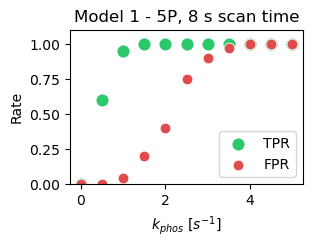

In [15]:
fig, ax = plt.subplots(figsize = (3,2))
sns.scatterplot(
    data=results9P_cutoff[results9P_cutoff['n_P']==5],
    x='k_phos',
    y='P_tpr',
    ax = ax, 
    s=90,
    c='#2BC96A'
)
sns.scatterplot(
    data=results9P_cutoff[results9P_cutoff['n_P']==5],
    x='k_phos',
    y='P_fpr',
    ax = ax, 
    alpha=1,
    s=60,
    c='#E04B4B'
)
ax.set_ylim([0,1.1])
ax.legend(['TPR', 'FPR'])
ax.set_ylabel('Rate')
ax.set_xlabel('$k_{phos}$ [$s^{-1}$]')
ax.set_title('Model 1 - 5P, {} s scan time'.format(cutoff))
#fig.savefig('/Users/koerbem/Documents/01_Klenerman_PhD/01_Projects/Cell_Cell_Contacts/2024_Manuscript/Sim_Figs/Fig5B_Model1_5P_TPRFPR.svg')

### Figure 5C

Text(0.5, 1.0, 'Model 1 - 5P, 8 s scan time')

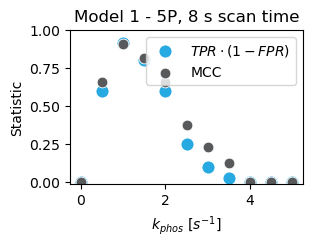

In [16]:
fig, ax = plt.subplots(figsize = (3,2))
sns.scatterplot(
    data=results9P_cutoff[results9P_cutoff['n_P']==5],
    x='k_phos',
    y='P_tpr-fpr',
    ax = ax, 
    s=90,
    c='#27AAE1'
)
sns.scatterplot(
    data=results9P_cutoff[results9P_cutoff['n_P']==5],
    x='k_phos',
    y='P_mcc',
    ax = ax, 
    s=60,
    c='#58595B'
)
ax.set_ylim([-0.01,1])
ax.legend(['$TPR\cdot(1-FPR)$', 'MCC'])
ax.set_ylabel('Statistic')
ax.set_xlabel('$k_{phos}$ [$s^{-1}$]')
ax.set_title('Model 1 - 5P, {} s scan time'.format(cutoff))
#fig.savefig('/Users/koerbem/Documents/01_Klenerman_PhD/01_Projects/Cell_Cell_Contacts/2024_Manuscript/Sim_Figs/Fig5B_Model1_5P_stats.svg')

### Figure S6 XXX

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

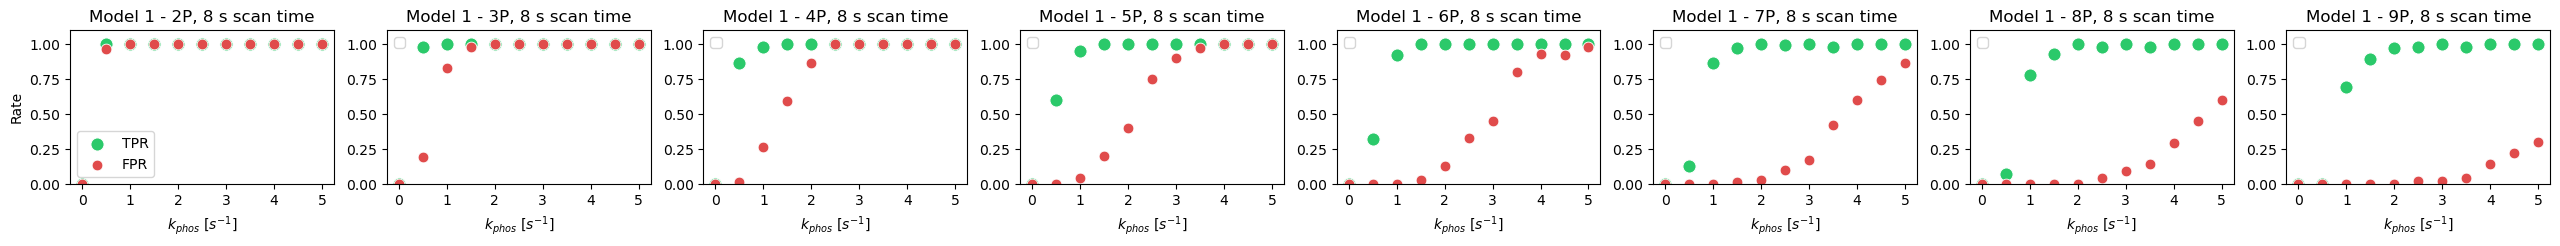

In [48]:
n_P = [2,3,4,5,6,7,8,9]

fig, ax = plt.subplots(1,len(n_P),figsize = (4*len(n_P),2))
for i, iP in enumerate(n_P):
    sns.scatterplot(
        data=results9P_cutoff[results9P_cutoff['n_P']==iP],
        x='k_phos',
        y='P_tpr',
        ax = ax[i], 
        s=90,
        c='#2BC96A'
    )
    sns.scatterplot(
        data=results9P_cutoff[results9P_cutoff['n_P']==iP],
        x='k_phos',
        y='P_fpr',
        ax = ax[i], 
        alpha=1,
        s=60,
        c='#E04B4B'
    )
    ax[i].set_ylim([0,1.1])
    ax[i].legend(['TPR', 'FPR'])
    ax[i].set_ylabel('Rate')
    ax[i].set_xlabel('$k_{phos}$ [$s^{-1}$]')
    ax[i].set_title('Model 1 - {}P, {} s scan time'.format(iP,cutoff))
    if i>0:
        ax[i].set_ylabel('')
        ax[i].legend()
#fig.savefig('/Users/koerbem/Documents/01_Klenerman_PhD/01_Projects/Cell_Cell_Contacts/2024_Manuscript/Sim_Figs/Fig5B_Model1_5P_TPRFPR.svg')

### Figure 5D

In [45]:
cutofflin = np.linspace(0,30,21) # s
n_P = [0,1,2,3,4,5,6,7,8,9]

results9P_stat = pd.DataFrame()
for iP in n_P:
    for icut in cutofflin:
        for i_kphos in np.unique(results9P_agg['k_phos']):  
            no_pmhc = np.sum(results9P_agg.loc[(results9P_agg['pMHC_mdens'] == 0) & (results9P_agg['k_phos']==i_kphos), 'time_to_{}P'.format(iP)] < icut)
            with_pmhc = np.sum(results9P_agg.loc[(results9P_agg['pMHC_mdens'] == 10) & (results9P_agg['k_phos']==i_kphos), 'time_to_{}P'.format(iP)] < icut)
            tp = with_pmhc # n with pMHC_dens == 10
            fp = no_pmhc # n with pMHC_dens == 0
            fn = n_sim - with_pmhc # simnum-n with pMHC_dens == 10
            tn = n_sim - no_pmhc # simnum-n with pMHC_dens == 0
        
            # depending on the plot, indent within kphos for loop or not
            iresult = {
                'model': 2,
                'cutoff': icut,
                'stat': tp/n_sim * (1-fp/n_sim),
                'n_P': iP,
                'k_phos': i_kphos,
                }
            results9P_stat = pd.concat([results9P_stat, pd.DataFrame(iresult, index=[0])], ignore_index=True)


Text(0.5, 1.0, 'Model 1 - 5P\nplotting $TPR\\cdot(1-FPR)$')

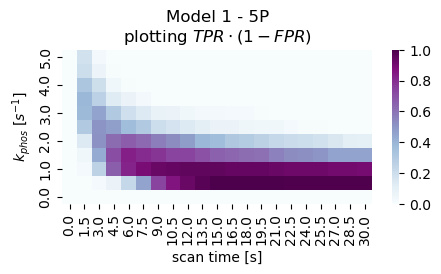

In [46]:
fig, ax = plt.subplots(figsize=(5,2))
sns.heatmap(data = results9P_stat[results9P_stat['n_P']==5].pivot(index='k_phos',columns='cutoff',values='stat'), cmap='BuPu', square=False, vmin=0, vmax=1)
ax.set_xlabel('scan time [s]')
ax.set_ylabel('$k_{phos}$ [$s^{-1}$]')
ax.invert_yaxis()
ax.set_title('Model 1 - 5P\nplotting $TPR\cdot(1-FPR)$')
#fig.savefig('/Users/koerbem/Documents/01_Klenerman_PhD/01_Projects/Cell_Cell_Contacts/2024_Manuscript/Sim_Figs/Fig5D_Model1_5P_scan-time.svg')

### Figure 5E

In [ ]:
cutofflin = np.linspace(0,30,21) # s
n_P = [0,1,2,3,4,5,6,7,8,9]

results9P_maxstat = pd.DataFrame()
for iP in n_P:
    for icut in cutofflin:
        max_k_phos = 0
        max_stat = 0
        for i_kphos in np.unique(results9P_agg['k_phos']):  
            no_pmhc = np.sum(results9P_agg.loc[(results9P_agg['pMHC_mdens'] == 0) & (results9P_agg['k_phos']==i_kphos), 'time_to_{}P'.format(iP)] < icut)
            with_pmhc = np.sum(results9P_agg.loc[(results9P_agg['pMHC_mdens'] == 10) & (results9P_agg['k_phos']==i_kphos), 'time_to_{}P'.format(iP)] < icut)
            tp = with_pmhc # n with pMHC_dens == 10
            fp = no_pmhc # n with pMHC_dens == 0
            fn = n_sim - with_pmhc # simnum-n with pMHC_dens == 10
            tn = n_sim - no_pmhc # simnum-n with pMHC_dens == 0

            if tp/n_sim * (1-fp/n_sim) > max_stat:
                max_k_phos = i_kphos
                max_stat = tp/n_sim * (1-fp/n_sim)
        
        iresult = {
            'model': 2,
            'cutoff': icut,
            'max_k_phos': max_k_phos,
            'max_stat': max_stat,
            'stat': tp/n_sim * (1-fp/n_sim),
            'n_P': iP,
            }
        results9P_maxstat = pd.concat([results9P_maxstat, pd.DataFrame(iresult, index=[0])], ignore_index=True)


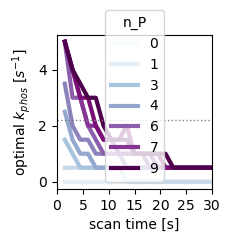

In [38]:
n_P = [3,4,5,6,7]

fig, ax = plt.subplots(figsize=(2,2)) 
#for iP in n_P:
#    sns.lineplot(data = results9P_cutoff[(results9P_cutoff['cutoff']>0)& (results9P_cutoff['n_P']==iP)], x = 'cutoff', y='max_k_phos', ax=ax, c='#1C75BC', lw=3, alpha=1-iP*0.1)
sns.lineplot(data = results9P_maxstat[(results9P_maxstat['cutoff']>0)], x = 'cutoff', y='max_k_phos', hue='n_P', ax=ax, palette='BuPu', lw=3)
#sns.lineplot(data = results9P_cutoff[(results9P_cutoff['cutoff']>0)& (results9P_cutoff['n_P']==4)], x = 'cutoff', y='max_k_phos', ax=ax, c='#5BA2D3', lw=3)
#sns.lineplot(data = results9P_cutoff[(results9P_cutoff['cutoff']>0)& (results9P_cutoff['n_P']==3)], x = 'cutoff', y='max_k_phos', ax=ax, c='#9CCFF2', lw=3)
ax.plot([0,30], [2.2,2.2], lw=1, ls=':', c='gray')
ax.set_xlabel('scan time [s]')
ax.set_ylabel('optimal $k_{phos}$ [$s^{-1}$]')
ax.set_xlim(0,30)
ax.set_xticks([0,5,10,15,20,25,30])
#fig.savefig('/Users/koerbem/Documents/01_Klenerman_PhD/01_Projects/Cell_Cell_Contacts/2024_Manuscript/Sim_Figs/Fig5E_Model1_5P_optimal_k-phos.svg')

### Fig S6

## Model 2

In [ ]:
# User input
folder = "/Users/koerbem/Documents/01_Klenerman_PhD/01_Projects/smoldyn/Model_9_5Phos_scan-k/"
columnnames_tcrs = ['timestep', 'species_type', 'state', 'x', 'y', 'sn']
columnnames = ['time', 'tcr', 'tcrb', 'tcrp1', 'tcrp1b', 'tcrp2', 'tcrp2b', 'tcrp3', 'tcrp3b', 'tcrp4', 'tcrp4b', 'tcrp5', 'tcrp5b', 'tcrall', 'cd45i', 'cd45o', 'cd45all'] # for model 8
r_sim = 1 # µm
r_c = 0.22 # µm
A_c = r_c**2 * np.pi
A_out = r_sim**2 * np.pi - A_c
dt = 0.002 #s
simtime = 30 # s
output_n = 10   # how often the lifetimes simulation output has been saved, in timesteps
n_sim = 50

In [ ]:
filelist = [i for i in listdir(folder) if ('tcrs' not in i) & ('lifetimes' not in i) & ('model_9' in i)]
filelist = np.sort(filelist)
folder = Path(folder)

In [ ]:
# Load triggering times
# Run lifetimes calculations separately, then read in output here
alldat = pd.DataFrame()

k_CD45 = [0.05, 0.01, 0.005, 0.001] # s-1 um-2
k_lck = [0.05, 0.01, 0.005, 0.001] # s-1 um-2
CD45_den = [600]
pMHC_mdens = [0,10]
CD45_exclusion = [0,20,40,60,80,100]

triggering = pd.DataFrame()

for ifile in filelist:
    if check_metadata_file(ifile, CD45_den,pMHC_mdens,CD45_exclusion,k_CD45,k_lck):
        print(ifile)
        dat, tracks, metadata, lifetimes = read_sim_output(ifile, folder, columnnames, columnnames_tcrs, dt=dt)

        # Unbound TCRPn
        tcrp5_trig_time = [i for i in lifetimes['tcrp5_trig_times'].values[0] if (i != False)] # to consider all triggering TCRs
        #trigtimes_p3 = lifetimes['tcrp3_trig_times'].values[0]
        #tcrp3_trig_time = [trigtimes_p3[i] for i in range(len(trigtimes_p3)) if ((trigtimes_p3[i] != False) and (lifetimes['tcrp3_trig_inside'].values[0][i]))] # to consider triggering TCRs only inside the contact
        if len(tcrp5_trig_time) > 0:
            tcrp5_trig_time = np.min(tcrp5_trig_time)*dt*output_n
        else:
            tcrp5_trig_time = simtime + 1
        tcrp5_lifetimes_inside_mean = lifetimes['tcrp5_lifetimes_inside'].values[0]
        if len(tcrp5_lifetimes_inside_mean) > 0:
            tcrp5_lifetimes_inside_mean = np.mean(tcrp5_lifetimes_inside_mean)*dt*output_n
        else: 
            tcrp5_lifetimes_inside_mean = 0

        # Bound TCRPn
        tcrp5b_trig_time = [i for i in lifetimes['tcrp5b_trig_times'].values[0] if (i != False)] # to consider only bound triggering TCRs
        #trigtimes_p3b = lifetimes['tcrp3b_trig_times'].values[0]
        #tcrp3b_trig_time = [trigtimes_p3b[i] for i in range(len(trigtimes_p3b)) if ((trigtimes_p3b[i] != False) and (lifetimes['tcrp3b_trig_inside'].values[0][i]))] # to consider triggering TCRs only inside the contact
        if len(tcrp5b_trig_time) > 0:
            tcrp5b_trig_time = np.min(tcrp5b_trig_time)*dt*output_n
        else:
            tcrp5b_trig_time = simtime + 1
        tcrp5b_lifetimes_inside_mean = lifetimes['tcrp5b_lifetimes_inside'].values[0]
        if len(tcrp5b_lifetimes_inside_mean) > 0:
            tcrp5b_lifetimes_inside_mean = np.mean(tcrp5b_lifetimes_inside_mean)*dt*output_n
        else: 
            tcrp5b_lifetimes_inside_mean = 0

        # Create dict
        trig = {
            'model': metadata['model'].values[0],
            'CD45_den':  metadata['CD45_den'].values[0],
            'pMHC_mdens': metadata['pMHC_mdens'].values[0],
            'k_off': metadata['k_off'].values[0],
            'k_CD45': metadata['k_CD45'].values[0],
            'CD45_exclusion': metadata['CD45_exclusion'].values[0],
            'CD45_exclusion_measured': lifetimes['CD45_exclusion_measured'],
            'k_lck': metadata['k_lck'].values[0],
            'repeat': metadata['repeat'].values[0],
            'tcrp5_trig_time': tcrp5_trig_time,
            'tcrp5b_trig_time': tcrp5b_trig_time,
            'tcrp5_lifetimes_inside_mean': tcrp5_lifetimes_inside_mean,
            'tcrp5b_lifetimes_inside_mean': tcrp5b_lifetimes_inside_mean,
        }
        triggering = pd.concat([triggering, pd.DataFrame(trig, index=[0])], ignore_index=True)




In [ ]:
scan_time = 8 # s

avgtrig = pd.DataFrame()
for ik in k_CD45:
    for jk in k_lck:
        for id in CD45_den:
            for ie in CD45_exclusion:
                cond_pos = (triggering['k_CD45']==ik) & (triggering['k_lck']==jk) & (triggering['CD45_den']==id) & (triggering['CD45_exclusion']==ie) & (triggering['pMHC_mdens']==10)
                cond_neg = (triggering['k_CD45']==ik) & (triggering['k_lck']==jk) & (triggering['CD45_den']==id) & (triggering['CD45_exclusion']==ie) & (triggering['pMHC_mdens']==0)
                tp = np.sum(triggering.loc[cond_pos,'tcrp5_trig_time']<scan_time)
                fn = np.sum(triggering.loc[cond_pos,'tcrp5_trig_time']>=scan_time)
                fp = np.sum(triggering.loc[cond_neg,'tcrp5_trig_time']<scan_time)
                tn = np.sum(triggering.loc[cond_neg,'tcrp5_trig_time']>=scan_time)
                tpr = tp / len(triggering.loc[cond_pos,'tcrp5_trig_time'])
                fpr = fp / len(triggering.loc[cond_neg,'tcrp5_trig_time'])
                stat_mcc = mcc(tp, tn, fp, fn)
                
                avg = {
                    'k_CD45': ik,
                    'k_lck': jk,
                    'CD45_den': id,
                    'CD45_exclusion': ie,
                    'tcrp5_trig_time_mean_pos': np.mean(triggering.loc[cond_pos,'tcrp5_trig_time']),
                    'tcrp5b_trig_time_mean_pos': np.mean(triggering.loc[cond_pos,'tcrp5b_trig_time']),
                    'tcrp5_trig_time_mean_neg': np.mean(triggering.loc[cond_neg,'tcrp5_trig_time']),
                    'tcrp5b_trig_time_mean_neg': np.mean(triggering.loc[cond_neg,'tcrp5b_trig_time']),
                    'tp': tp,
                    'fn': fn, 
                    'tn': tn,
                    'fp': fp,
                    'tpr': tpr,
                    'fpr': fpr,
                    'stat': tpr * (1-fpr),
                    'mcc': stat_mcc,
                }
                avgtrig = pd.concat([avgtrig, pd.DataFrame(avg, index=[0])], ignore_index=True)